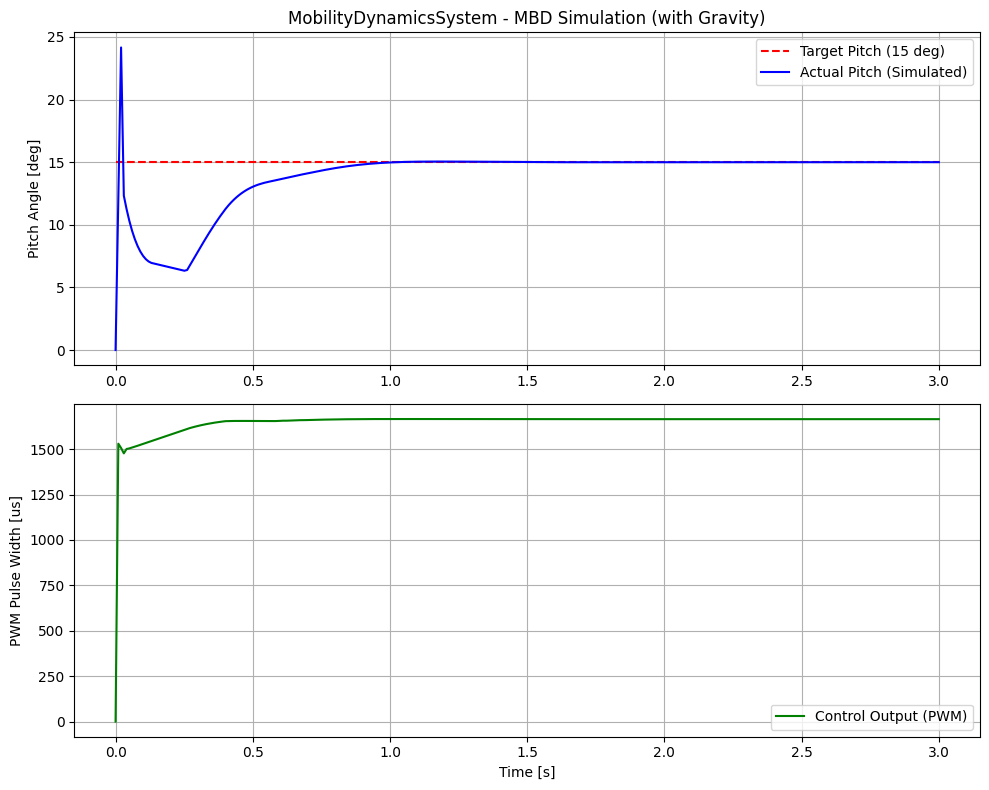

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- シミュレーション設定 ---
dt = 0.01          # 制御周期 10ms (実機と同じ)
sim_time = 3.0     # シミュレーション時間 3秒
n_steps = int(sim_time / dt)

# --- 物理モデルのパラメータ ---
tau = 0.1          # サーボモーターの応答遅れ（時定数）
gravity_max_droop = 8.0 # 重力による最大垂れ下がり角度（度）

# --- PIDゲイン（実機で試している値をセット） ---
Kp = 60
Ki = 50
Kd = -2.0

# --- データ記録用配列 ---
time_data = np.linspace(0, sim_time, n_steps)
pitch_data = np.zeros(n_steps)
pwm_data = np.zeros(n_steps)
target_data = np.ones(n_steps) * 15.0  # 目標角度 15度

# --- 状態変数 ---
current_pitch = 0.0
previous_pitch = 0.0
current_velocity = 0.0
integral_error = 0.0
current_pwm = 1500.0  # 初期PWM（0度）

# --- シミュレーションループ ---
for i in range(1, n_steps):
    target = target_data[i]
    
    # === 1. コントローラ部（C言語マイコン側の処理） ===
    error = target - current_pitch
    derivative = current_velocity
    
    # PID計算
    error_abs = abs(error)

    if error_abs > 10.0:
        # 1. 大ズレ：バンバン制御
        speed = 3000.0 if error > 0 else -3000.0
    elif error_abs > 4.0:
        # 2. 接近フェーズ（4度〜10度）
        speed = (Kp * error) + (-2.0 * derivative)
    elif error_abs > 2.0:
        # 3. 最終着地フェーズ（2度〜10度※元のコメントママ）
        active_error = (error - 2.0) if error > 0.0 else (error + 2.0)
        speed = (Kp * active_error) + (Kd * derivative)
    else:
        # 4. 不感帯（ノイズ以上の動きがあればブレーキ優先）
        if derivative > 5.0 or derivative < -5.0:
            speed = Kd * derivative
        else:
            speed = Ki * error  # ← ★ここ！！！
    
    # 実機同様、PWMに足し込む（積分動作）
    current_pwm += speed * dt
    
    # PWMのリミット処理（フェールセーフ）
    if current_pwm > 2400.0: current_pwm = 2400.0
    elif current_pwm < 600.0: current_pwm = 600.0
        
    pwm_data[i] = current_pwm
    
    # === 2. プラント部（ハードウェア・物理の現実世界） ===
    # PWM信号からSG90が目指す物理角度への変換 (仮に10us=1度とする)
    pwm_to_deg = 1.0 / 10.0
    servo_target_pitch = (current_pwm - 1500.0) * pwm_to_deg
    
    # 重力によるモーメント（傾くほど下に引っ張られる外乱）
    # 振り子なので sin(θ) に比例して負荷がかかる
    gravity_disturbance = gravity_max_droop * np.sin(np.radians(current_pitch))
    
    # モーターが実際に到達できる角度（重力に負けて少し垂れ下がる）
    actual_target = servo_target_pitch - gravity_disturbance
    
    # --- 【ここに追加】SG90のバックラッシュ（ギアの遊び）モデル ---
    backlash_gap = 1.5 # ギアの遊びを ±1.5度 と仮定
    
    # モーターが遊びのスキマを埋めきるまでは、ジンバル本体には力が伝わらない
    if actual_target > current_pitch + backlash_gap:
        actual_target -= backlash_gap  # 引っ張る
    elif actual_target < current_pitch - backlash_gap:
        actual_target += backlash_gap  # 押し戻す
    else:
        actual_target = current_pitch  # スキマの中でモーターが空回りしている状態


    # SG90の追従遅れ（1次遅れ系）
    current_pitch += (actual_target - current_pitch) * (dt / tau)
    
    # センサーが読み取る角速度（微分）を逆算して次回のループへ
    current_velocity = (current_pitch - previous_pitch) / dt
    previous_pitch = current_pitch
    
    # 記録
    pitch_data[i] = current_pitch

# --- グラフ描画 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 上段：角度のグラフ
ax1.plot(time_data, target_data, 'r--', label='Target Pitch (15 deg)')
ax1.plot(time_data, pitch_data, 'b-', label='Actual Pitch (Simulated)')
ax1.set_title('MobilityDynamicsSystem - MBD Simulation (with Gravity)')
ax1.set_ylabel('Pitch Angle [deg]')
ax1.grid(True)
ax1.legend()

# 下段：PWM出力のグラフ
ax2.plot(time_data, pwm_data, 'g-', label='Control Output (PWM)')
ax2.set_ylabel('PWM Pulse Width [us]')
ax2.set_xlabel('Time [s]')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()